In [67]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models
from keras.src.utils import image_dataset_from_directory
from keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from keras.regularizers import l2

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K

In [85]:
def plot_sample_predictions(model, features, images, labels, title='Sample Predictions'):
    predictions = model.predict(features)
    fig, axes = plt.subplots(2, 5, figsize=(10, 6))
    fig.patch.set_facecolor('#e8e8e8')
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i])
            pred = predictions[i][0]
            true_label = dataset.class_names[int(labels[i])]
            pred_label = dataset.class_names[int(pred > 0.5)]
            ax.set_title(f'True: {true_label}\nPred: {pred_label} ({pred:.2f})', fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
def plot_confusion_matrix(model, features, labels, title='Confusion Matrix'):
    pred_labels = (model.predict(features) > 0.5).astype(int).flatten()
    cm = confusion_matrix(labels, pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
    disp.plot(cmap='Blues')
    plt.title(title)
    plt.show()



In [69]:
dataset = image_dataset_from_directory(
    'Resources',
    image_size=(256, 256),
    batch_size=None,
    label_mode='binary',
    shuffle=True,
    seed=42
)
xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy])
y = np.array([item[1].numpy() for item in xy])
print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)
x = x / 255.0
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)
y_train = y_train.flatten()
y_val = y_val.flatten()
y_test = y_test.flatten()

Found 163 files belonging to 2 classes.
Total images: (163, 256, 256, 3)
Total labels: (163, 1)
Class names: ['Chairs', 'Pens']


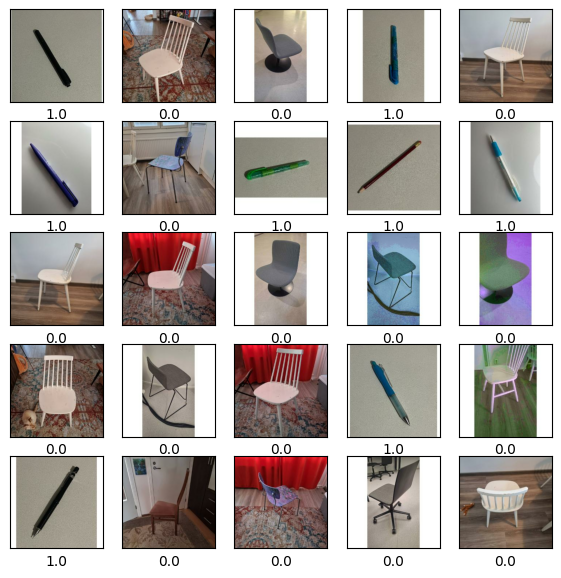

In [70]:
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

In [71]:
batch_size = 256
epochs = 50
input_shape = (256, 256, 3)

In [90]:
inputs = keras.Input(shape=input_shape)
x = layers.RandomRotation(0.1)(inputs)
x = layers.RandomZoom(0.1)(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, 2)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = models.Model(inputs, outputs)

In [91]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [74]:
balancedweights = dict(enumerate(compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)))

In [75]:
history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2, class_weight=balancedweights)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5192 - loss: 0.7024 - val_accuracy: 0.2308 - val_loss: 0.7516
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3077 - loss: 0.6987 - val_accuracy: 0.2308 - val_loss: 0.7757
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.3077 - loss: 0.6970 - val_accuracy: 0.2308 - val_loss: 0.7688
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3077 - loss: 0.7021 - val_accuracy: 0.2308 - val_loss: 0.7440
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3077 - loss: 0.6972 - val_accuracy: 0.2308 - val_loss: 0.7174
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4038 - loss: 0.6956 - val_accuracy: 0.3077 - val_loss: 0.7019
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4615 - loss: 0.6991 - val_accuracy: 0.3077 - val_loss: 0.7145
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.4519 - loss: 0.6926 - val_accuracy: 0.2692 - val_loss: 0.7383
Epoch 9/50
1/1

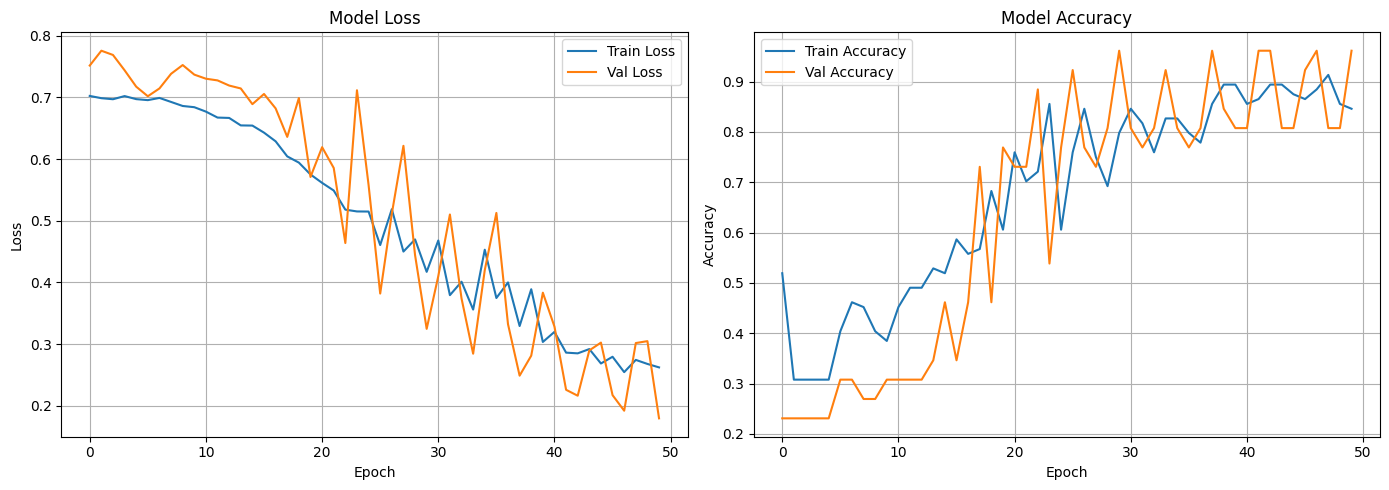

1/1 - 0s - 263ms/step - accuracy: 0.8235 - loss: 0.3078

Test accuracy: 0.8235
Test loss: 0.3078


In [76]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(history.history["loss"], label="Train Loss")
axs[0].plot(history.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(history.history["accuracy"], label="Train Accuracy")
axs[1].plot(history.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

In [77]:
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])
train_scores = model.evaluate(x_train, y_train, verbose=2)
print("Train loss:", train_scores[0])
print("Train accuracy:", train_scores[1])

1/1 - 0s - 230ms/step - accuracy: 0.8235 - loss: 0.3078
Test loss: 0.30778583884239197
Test accuracy: 0.8235294222831726
5/5 - 1s - 218ms/step - accuracy: 0.9000 - loss: 0.2164
Train loss: 0.2163999080657959
Train accuracy: 0.8999999761581421


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


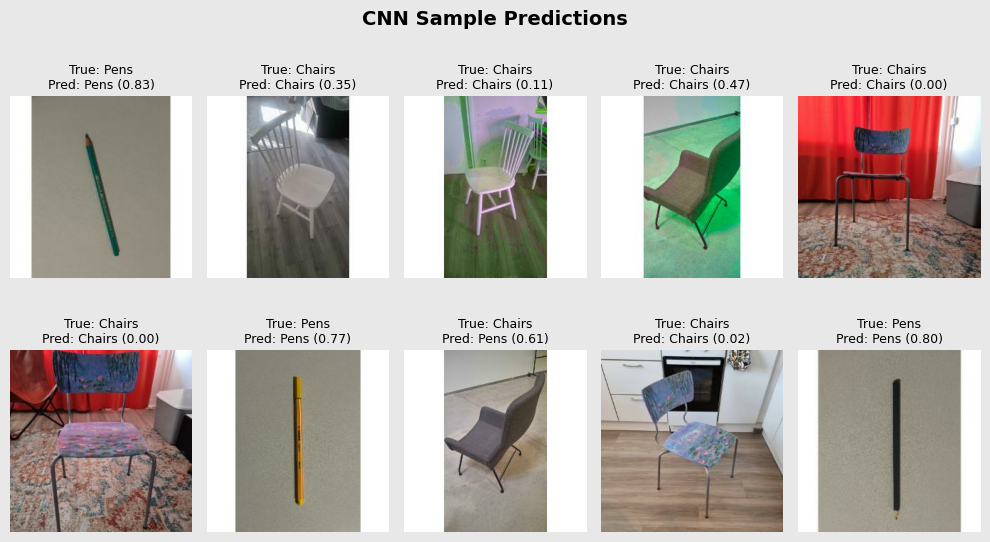

In [78]:
plot_sample_predictions(model, x_test, x_test, y_test, title='CNN Sample Predictions')

## MobileNetV2 with Transfer Learning

In [79]:
conv_base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(256, 256, 3)
)
conv_base.trainable = False

C:\Users\veikk\AppData\Local\Temp\ipykernel_7388\3532321540.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  conv_base = MobileNetV2(


In [80]:
print("Extracting features from training set...")
train_features = conv_base.predict(x_train, batch_size=64, verbose=1)
print("Extracting features from validation set...")
val_features = conv_base.predict(x_val, batch_size=64, verbose=1)
print("Extracting features from test set...")
test_features = conv_base.predict(x_test, batch_size=64, verbose=1)
print(f"\nExtracted feature shapes:")
print(f"  Train: {train_features.shape}")
print(f"  Val:   {val_features.shape}")
print(f"  Test:  {test_features.shape}")

Extracting features from training set...
2/3 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000014C7283B280> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step
Extracting features from validation set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
Extracting features from test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 665ms/step

Ex

In [81]:
train_features_flat = train_features.reshape(train_features.shape[0], -1)
val_features_flat = val_features.reshape(val_features.shape[0], -1)
test_features_flat = test_features.reshape(test_features.shape[0], -1)
print(f"Flattened feature vector length: {train_features_flat.shape[1]}")

Flattened feature vector length: 81920


In [82]:
model2 = keras.Sequential([
    layers.Input(shape=(train_features_flat.shape[1],)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
model2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [83]:
secondhistory = model2.fit(
    train_features_flat, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(val_features_flat, y_val)
)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 707ms/step - accuracy: 0.7294 - loss: 0.5642 - val_accuracy: 1.0000 - val_loss: 0.0314
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - accuracy: 0.9845 - loss: 0.0394 - val_accuracy: 1.0000 - val_loss: 1.6424e-04
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 3.4141e-06
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 434ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 1.6868e-07
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 477ms/step - accuracy: 1.0000 - loss: 6.5886e-04 - val_accuracy: 1.0000 - val_loss: 1.5904e-08
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 469ms/step - accuracy: 1.0000 - loss: 1.4388e-05 - val_accuracy: 1.0000 - val_loss: 2.5231e-09
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 445ms/step - accuracy: 1.0000 - loss: 1.2432e-06 - val_accuracy: 1.0000 - val_loss: 5.8175e-10
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step - accuracy: 1.0000 - loss: 8.793

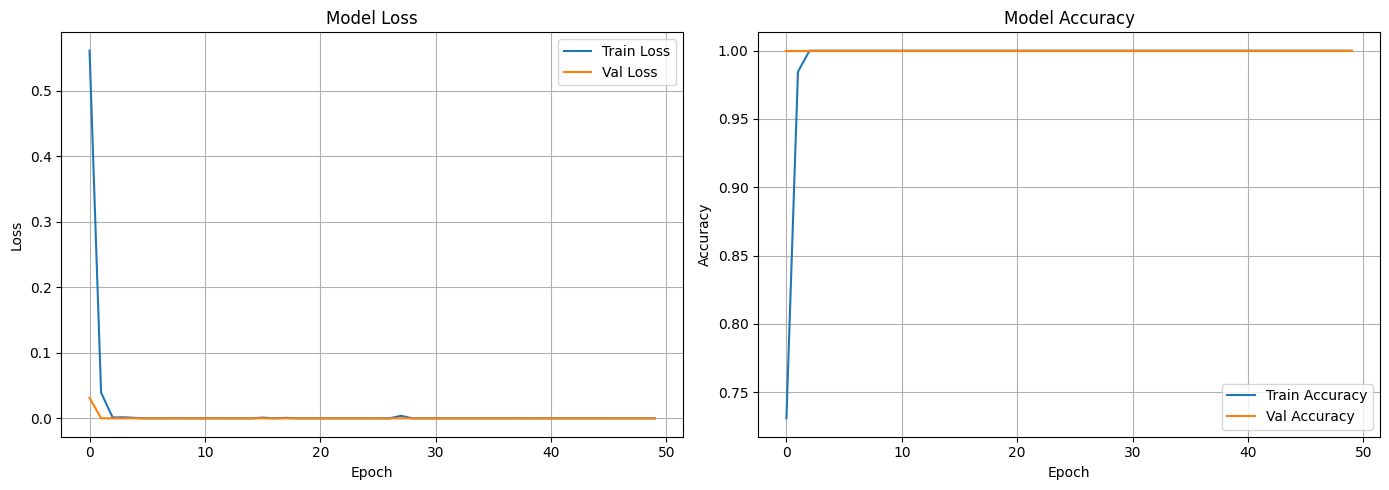

1/1 - 0s - 100ms/step - accuracy: 1.0000 - loss: 5.6077e-14

Test accuracy: 1.0000
Test loss: 0.0000


In [86]:
fig2, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(secondhistory.history["loss"], label="Train Loss")
axs[0].plot(secondhistory.history["val_loss"], label="Val Loss")
axs[0].set_title("Model Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True)
axs[1].plot(secondhistory.history["accuracy"], label="Train Accuracy")
axs[1].plot(secondhistory.history["val_accuracy"], label="Val Accuracy")
axs[1].set_title("Model Accuracy")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy")
axs[1].legend()
axs[1].grid(True)
plt.tight_layout()
plt.show()
test_loss, test_acc = model2.evaluate(test_features_flat, y_test, verbose=2)
print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


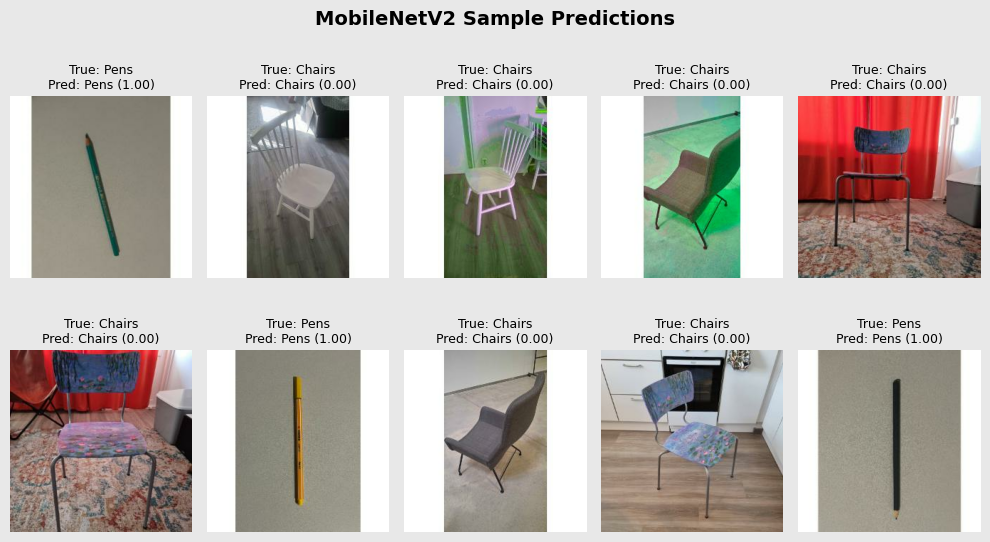

In [88]:
plot_sample_predictions(model2, test_features_flat, x_test, y_test, title='MobileNetV2 Sample Predictions')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


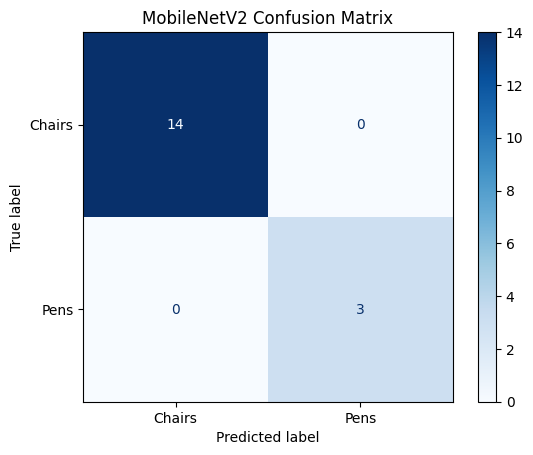

In [89]:
plot_confusion_matrix(model2, test_features_flat, y_test, title='MobileNetV2 Confusion Matrix')